# 03 · CNN desde cero
Entrenamos una CNN propia (sin pesos preentrenados) como **línea base**. Con un dataset chico es esperable cierto overfitting: ese resultado es parte del análisis y motiva el transfer learning.

In [1]:
# =========================================================
# CONFIGURACIÓN  ·  EDITAR BASE_DIR si hace falta
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta de Drive que CONTIENE "Imagenes OK" y "Imagenes Patologicas".
# Ajustá esta ruta a donde estén tus carpetas.
BASE_DIR = '/content/drive/MyDrive/TP_Final Aprendizaje Automatico'

OK_DIR  = os.path.join(BASE_DIR, 'Imagenes OK')
PAT_DIR = os.path.join(BASE_DIR, 'Imagenes Patologicas')

# Carpeta donde se guardará la partición train/val/test (notebook 02)
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
# Carpeta donde se guardarán los modelos entrenados
MODELS_DIR  = os.path.join(BASE_DIR, 'modelos')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparámetros globales compartidos
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# Las carpetas se ordenan alfabéticamente: 'ok'=0, 'patologica'=1
# => la clase POSITIVA (la que nos importa) es 'patologica' = 1
CLASS_NAMES = ['ok', 'patologica']
print('OK_DIR :', OK_DIR)
print('PAT_DIR:', PAT_DIR)

Mounted at /content/drive
OK_DIR : /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK
PAT_DIR: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes Patologicas


## 1. Reconstruir datasets desde Drive (copia local rápida)

In [2]:
import shutil, tensorflow as tf

# Copiamos la partición de Drive al disco local de Colab (lecturas mucho más rápidas)
LOCAL = '/content/dataset'
if os.path.exists(LOCAL):
    shutil.rmtree(LOCAL)
shutil.copytree(DATASET_DIR, LOCAL)

def make_ds(subset, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL, subset),
        labels='inferred', label_mode='int',
        class_names=CLASS_NAMES,
        color_mode='rgb', image_size=IMG_SIZE,
        batch_size=BATCH, shuffle=shuffle, seed=SEED,
    )

train_ds = make_ds('train', shuffle=True)
val_ds   = make_ds('val',   shuffle=False)
test_ds  = make_ds('test',  shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 308 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 67 files belonging to 2 classes.


In [3]:
import json
with open(os.path.join(DATASET_DIR, 'class_weight.json')) as f:
    class_weight = json.load(f)
class_weight = {int(k): v for k, v in class_weight.items()}
print('class_weight =', class_weight)

class_weight = {0: 0.9005847953216374, 1: 1.1240875912408759}


## 2. Arquitectura de la CNN

In [4]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

def build_cnn():
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)          # activo solo en entrenamiento
    x = layers.Rescaling(1./255)(x)        # normalización [0,1]
    # 5 bloques Conv+BN+Pool: 224 -> 112 -> 56 -> 28 -> 14 -> 7
    for filtros in [32, 64, 128, 128, 128]:
        x = layers.Conv2D(filtros, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    # Etapa de clasificación (slide "Flatten y Fully-connected")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation='softmax')(x)   # 2 clases: ok / patologica
    return models.Model(inputs, outputs, name='cnn_desde_cero')

cnn = build_cnn()
cnn.summary()

Model: "cnn_desde_cero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           51

 Total params: 423,874 (1.62 MB)

 Trainable params: 422,914 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 3. Compilación y callbacks

In [5]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ckpt_path = os.path.join(MODELS_DIR, 'cnn_desde_cero.keras')
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',
        patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss',
        mode='min', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6),
]

## 4. Entrenamiento

In [6]:
history = cnn.fit(
    train_ds, validation_data=val_ds,
    epochs=50, class_weight=class_weight, callbacks=callbacks)
cnn.save(ckpt_path)
print('Modelo guardado en', ckpt_path)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 496ms/step - accuracy: 0.5422 - loss: 0.7706 - val_accuracy: 0.4394 - val_loss: 0.7028 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5032 - loss: 0.7412 - val_accuracy: 0.4394 - val_loss: 0.7165 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.6234 - loss: 0.6306 - val_accuracy: 0.4394 - val_loss: 0.7799 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.6136 - loss: 0.6305 - val_accuracy: 0.4394 - val_loss: 0.8485 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.6916 - loss: 0.5852 - val_accuracy: 0.4394 - val_loss: 0.9630 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.6916 - loss: 0.5852 - val_accuracy: 0.4394 - val_loss: 1.2589 - learning_rate: 5.0000e-04
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.6818 - loss: 0.56

## 5. Curvas de entrenamiento

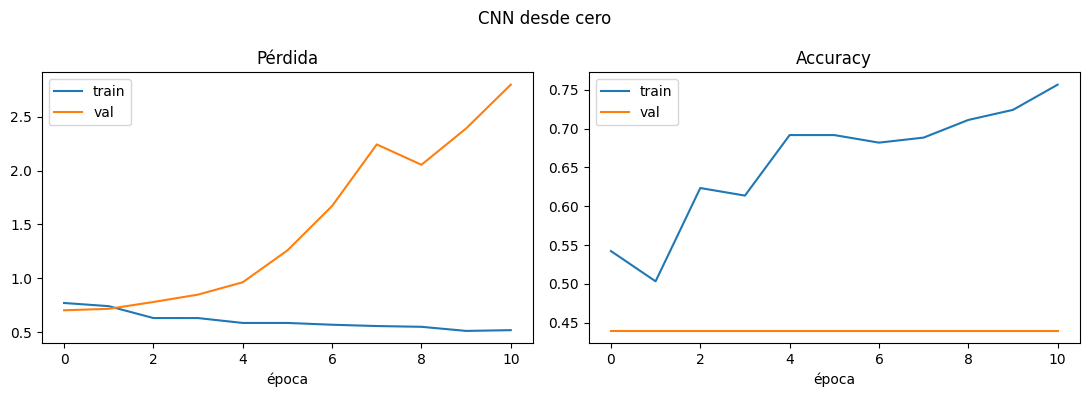

In [7]:
import matplotlib.pyplot as plt

def plot_history(h, titulo=''):
    hist = h.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (m, nombre) in zip(axes, [('loss','Pérdida'),('accuracy','Accuracy')]):
        ax.plot(hist[m], label='train')
        ax.plot(hist['val_'+m], label='val')
        ax.set_title(nombre); ax.set_xlabel('época'); ax.legend()
    fig.suptitle(titulo); plt.tight_layout(); plt.show()

plot_history(history, 'CNN desde cero')

## 6. Evaluación rápida sobre test

In [9]:
res = cnn.evaluate(test_ds, return_dict=True)
for k, v in res.items():
    print(f'{k:10s}: {v:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4478 - loss: 0.7031    
accuracy  : 0.4478
loss      : 0.7031


> El análisis fino (matriz de confusión, comparación, umbral) se hace en **05_evaluacion_comparacion.ipynb**.\n\nPróximo paso → **04_transfer_learning.ipynb**.